In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import os

print(os.path.exists(r"D:\RAMYA DOC\Mask_NoMask"))
print(os.listdir(r"D:\RAMYA DOC\Mask_NoMask"))

True
['without_mask', 'with_mask']


In [3]:
import cv2
import matplotlib.pyplot as plt

In [4]:
path1 = r"D:\RAMYA DOC\Mask_NoMask"  # path of folders
cate = ['with_mask','without_mask']

image_size = 200   # hyper parameter

input_image = []   # empty list

for i in cate:
    folders = os.path.join(path1, i)
    label = cate.index(i)
    for image in os.listdir(folders):
        image_path = os.path.join(folders, image)
        image_array = cv2.imread(image_path)
        image_array = cv2.resize(image_array, (image_size, image_size))
        input_image.append([image_array, label])

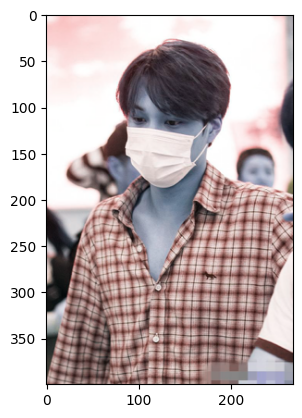

In [5]:
plt.imshow(cv2.imread("D:\RAMYA DOC\Mask_NoMask\with_mask\image_195.png"))

In [6]:
len(input_image)

440

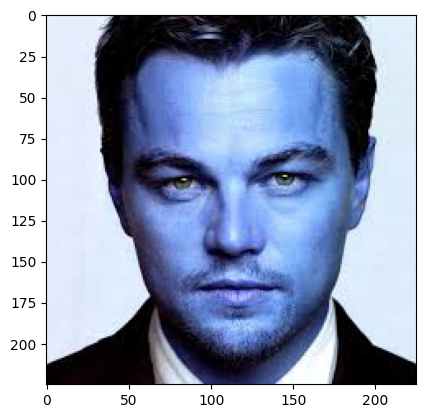

In [7]:
plt.imshow(cv2.imread("D:\RAMYA DOC\Mask_NoMask\without_mask\image_25.png"))

In [8]:
# sampling divide data into train and test
np.random.shuffle(input_image)

In [9]:
train = input_image[0:352]
test = input_image[352:440]

In [10]:
# Train split (seprate X (pixcel) and Y)
X_train = []
Y_train = []

for X_values, labels in train:
    X_train.append(X_values)
    Y_train.append(labels)

In [11]:
# Test split
X_test = []
Y_test = []

for X_values, labels in train:
    X_test.append(X_values)
    Y_test.append(labels)

In [12]:
# Convert to numpy arrays
X_train = np.array(X_train)
Y_train = np.array(Y_train)

X_test = np.array(X_test)
Y_test = np.array(Y_test)

In [13]:
# Normalize
X_train = X_train / 255
X_test = X_test / 255

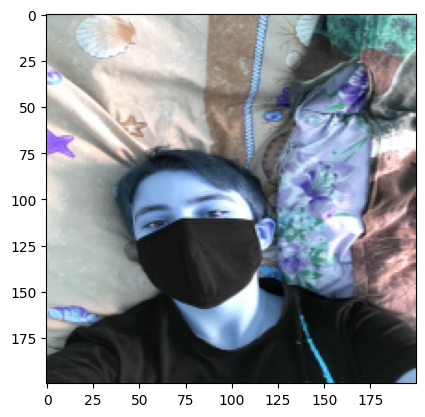

In [14]:
# Show sample image
plt.imshow(X_train[20])

In [15]:
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2)))

# above is 1st level of conv and pooling o/p of this is i/p for below

model.add(Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2)))

model.add(Flatten())

model.add(Dense(256, activation = 'relu', input_shape = X_train.shape[1:]))
model.add(Dense(2, activation = 'softmax'))

D:\RAMYA DOC\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, Y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.5516 - loss: 3.7617 - val_accuracy: 0.8592 - val_loss: 0.4227
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7438 - loss: 0.5353 - val_accuracy: 0.7887 - val_loss: 0.4728
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 823ms/step - accuracy: 0.8505 - loss: 0.3522 - val_accuracy: 0.9014 - val_loss: 0.3349
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 928ms/step - accuracy: 0.9253 - loss: 0.2486 - val_accuracy: 0.8873 - val_loss: 0.2812
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 888ms/step - accuracy: 0.9537 - loss: 0.1623 - val_accuracy: 0.8873 - val_loss: 0.3133
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 791ms/step - accuracy: 0.9751 - loss: 0.0780 - val_accuracy: 0.9155 - val_loss: 0.3406
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 940ms/step - accuracy: 1.0000 - loss: 0.0307 - val_accuracy: 0.8873 - val_loss: 0.4836
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 803ms/step - accuracy: 1.0000 - loss: 0.0163 - val_accuracy: 0.9296 - val_loss: 0.50

In [17]:
pred = model.predict(X_test)
pred_cat = pred.argmax(axis = 1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step


In [20]:
from sklearn.metrics import confusion_matrix
tab =confusion_matrix(Y_test, pred_cat)
tab
print (classification_report(Y_test , pred_cat))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       171
           1       0.98      0.99      0.99       181

    accuracy                           0.99       352
   macro avg       0.99      0.99      0.99       352
weighted avg       0.99      0.99      0.99       352



In [21]:
tab.diagonal().sum() / tab.sum()

np.float64(0.9857954545454546)

In [22]:
model.save("mask_no_mask.h5")